# Introduction 

## Working with PDB Files
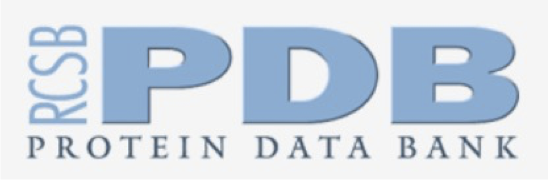


Go to website: https://www.rcsb.org

Search for protein structures by PDB ID or keywords.
Download PDB (structure) and sequence (FASTA) files.

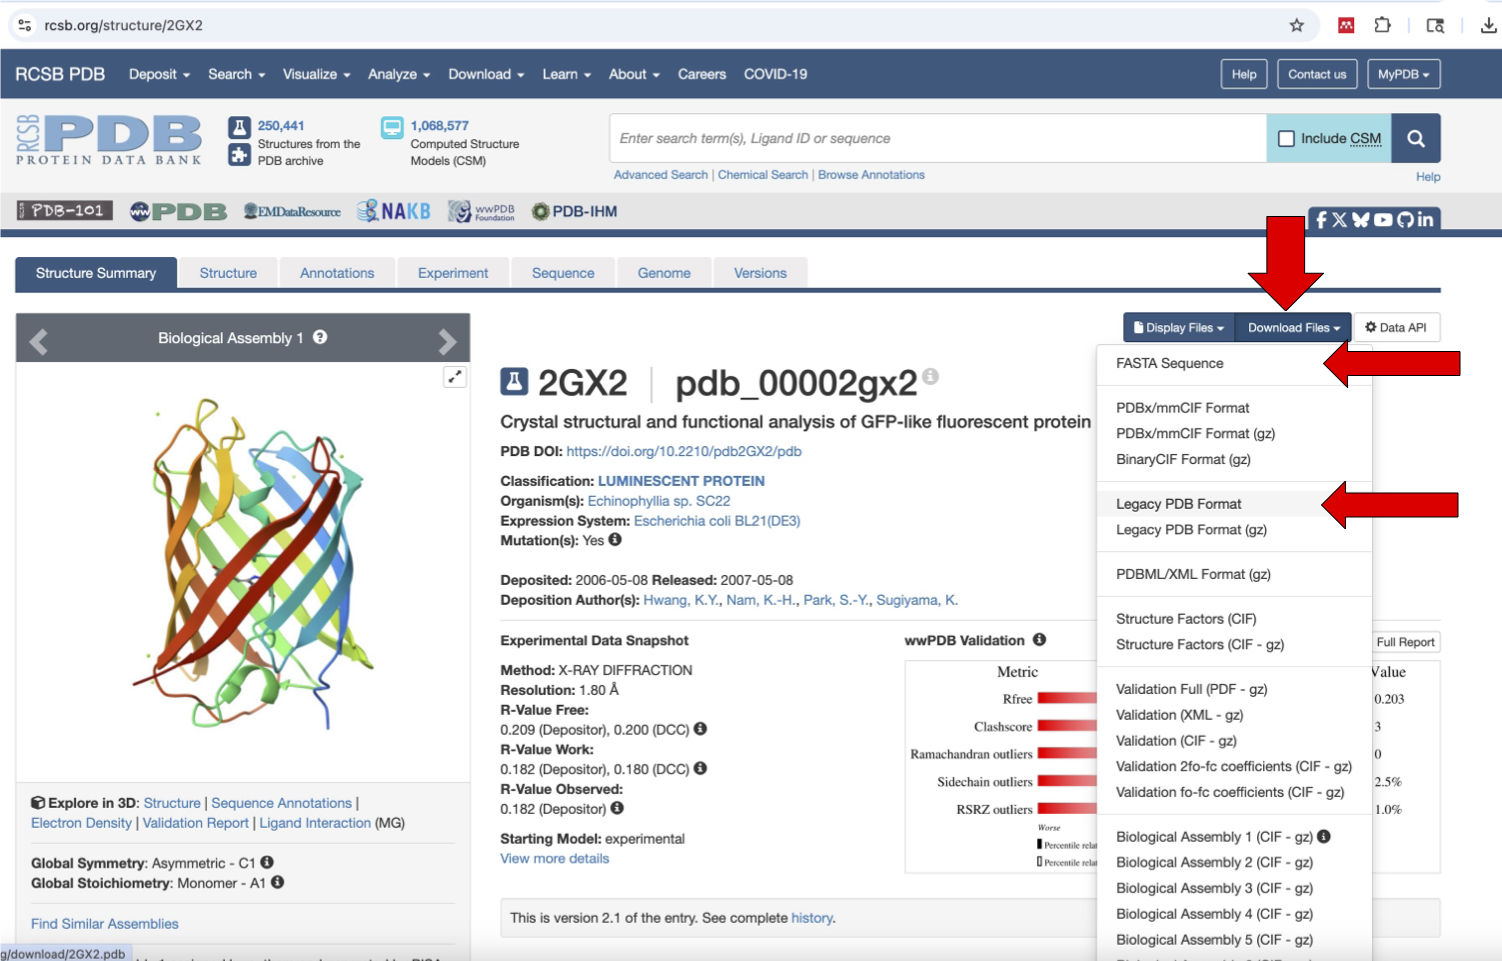


PDB files are structured as follows:

![pdb_file_explained.png](<attachment:pdb_file_explained.png>)


FASTA files are simple text files that save the amino acid residue information per chain. Such as:

```
>2GX2_1|Chain A|fluorescent protein Dronpa|Echinophyllia sp. SC22 (301887)
MRGSHHHHHHGSLVPRGSMVSVIKPDMKIKLRMEGAVNGHPFAIEGVGLGKPFEGKQSMDLKVKEGGPLPFAYDILTTVFSYGNRVFAKYPENIVDYFKQSFPEGYSWERSMNYEDGGICNATNDITLDGDCYIYEIRFDGVNFPANGPVMQKRTVKWEPSTEKLYVRDGVLKGDVNMALSLEGGGHYRCDFKTTYKAKKVVQLPDYHFVDHHIEIKSHDKDYSNVNLHEHAEAHSELPRQAK
>2GX2_2|Chainb B|fluorescent protein Dronpa|Echinophyllia sp. SC22 (301887)
MRGSHHHHHHGSLVPRGSMVSVIKPDMKIKLRMEGAVNGHPFAIEGVGLGKPFEGKQSMDLKVKEGGPLPFAYDILTTVFSYGNRVFAKYPENIVDYFKQSFPEGYSWERSMNYEDGGICNATNDITLDGDCYIYEIRFDGVNFPANGPVMQKRTVKWEPSTEKLYVRDGVLKGDVNMALSLEGGGHYRCDFKTTYKAKKVVQLPDYHFVDHHIEIKSHDKDYSNVNLHEHAEAHSELPRQAK

```

## Loading Datafiles

In [3]:
# CELL — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [1]:
# CELL — Set up paths and load all PDB files across all subfolders
import os
import glob
base_path = '/content/drive/MyDrive/Protein_Structure_class'

In [2]:
# Automatically finds all PDB files in all subfolders
pdb_files = glob.glob(os.path.join(base_path, '**/*.pdb'), recursive=True)

# Organize into a dictionary by folder name
pdb_dict = {}
for pdb_path in pdb_files:
    folder_name = os.path.basename(os.path.dirname(pdb_path))
    if folder_name not in pdb_dict:
        pdb_dict[folder_name] = []
    pdb_dict[folder_name].append(pdb_path)

# Print summary so students can confirm what loaded
for folder, files in pdb_dict.items():
    print(f"\n {folder}:")
    for f in files:
        print(f"   - {os.path.basename(f)}")

**Visualising Protein Strutuctues in Colab Notebook**

Most commonly, pymol is used for protein visualisation (https://www.pymol.org/)
However, in interactive notebooks py3Dmol is most convenient!

In [8]:
!pip install py3Dmol
import py3Dmol
!pip install -U prody
import prody

view = py3Dmol.view()
view.addModel(open('./2GX2.pdb', 'r').read(),'pdb')
view.setBackgroundColor('white')
view.setStyle({'chain':'A'}, {'cartoon': {'color':'purple'}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Structure Superposition
Superposition means finding a rigid-body rotation and translation that best overlays two structures.
Here we compare chain A of 6L27 (mutant GFP) to chain A of 2GX2 (reference).

Two ways to define which residues correspond:
1) index-based (structural) pairing: residue 1 in one structure is paired with residue 1 in the other, up to the shorter length.
   This is quick but can fail if the constructs differ by insertions/deletions or missing termini.
2) sequence-aligned pairing: first align the amino-acid sequences, then only fit residues aligned without gaps.
   This is the safer default when sequences/constructs differ.

We will superpose 6L27 (mutant GFP) onto 2GX2 (reference) using BioPython’s Superimposer.
RMSD is reported for the atoms used in the fit (Cα or backbone).

If you are superposing two proteins with the same sequence, the sequence alignment can be skipped.

In [6]:
from pathlib import Path
from Bio.PDB import PDBParser, Superimposer, PDBIO
from Bio.SeqUtils import seq1
from Bio.Align import PairwiseAligner

# Paths (adjust if needed)
ref_pdb = Path("2GX2.pdb")  # reference GFP
mob_pdb = Path("6L27.pdb")  # mutant GFP to move onto reference
CHAIN = "A"

parser = PDBParser(QUIET=True)

def load_chain(pdb_path, chain_id="A"):
    s = parser.get_structure(pdb_path.stem, str(pdb_path))
    return s, s[0][chain_id]

def standard_residues(chain):
    return [r for r in chain.get_residues() if r.id[0] == " "]

def one_letter_seq(residues):
    out = []
    for r in residues:
        try:
            out.append(seq1(r.get_resname()))
        except Exception:
            out.append("X")
    return "".join(out)

def atom_pairs_from_residue_pairs(res_pairs, atom_names):
    ref_atoms, mob_atoms = [], []
    for r_ref, r_mob in res_pairs:
        if all(a in r_ref and a in r_mob for a in atom_names):
            for a in atom_names:
                ref_atoms.append(r_ref[a])
                mob_atoms.append(r_mob[a])
    return ref_atoms, mob_atoms

def index_based_pairs(ref_chain, mob_chain):
    ref_res = [r for r in standard_residues(ref_chain) if "CA" in r]
    mob_res = [r for r in standard_residues(mob_chain) if "CA" in r]
    n = min(len(ref_res), len(mob_res))
    return list(zip(ref_res[:n], mob_res[:n]))

def seq_aligned_pairs(ref_chain, mob_chain):
    ref_res = standard_residues(ref_chain)
    mob_res = standard_residues(mob_chain)
    ref_seq = one_letter_seq(ref_res)
    mob_seq = one_letter_seq(mob_res)

    aligner = PairwiseAligner()
    aligner.mode = "global"
    aligner.match_score = 1.0
    aligner.mismatch_score = 0.0
    aligner.open_gap_score = -1.0
    aligner.extend_gap_score = -0.1

    aln = aligner.align(mob_seq, ref_seq)[0]
    mob_blocks, ref_blocks = aln.aligned

    pairs = []
    for (ms, me), (rs, re) in zip(mob_blocks, ref_blocks):
        for k in range(me - ms):
            pairs.append((ref_res[rs + k], mob_res[ms + k]))
    return pairs

def fit_and_rmsd(ref_pdb, mob_pdb, res_pairs, atom_names, out_pdb=None):
    # reload fresh (so fits don't accumulate)
    ref_struct, ref_chain = load_chain(ref_pdb, CHAIN)
    mob_struct, mob_chain = load_chain(mob_pdb, CHAIN)

    # rebuild pairs using the freshly loaded residues by matching by position in the residue list
    # simplest: reuse res_pairs indices by sequence-based pairing built from these same chains
    # so: res_pairs should be created from ref_chain/mob_chain you pass in
    ref_atoms, mob_atoms = atom_pairs_from_residue_pairs(res_pairs, atom_names)

    sup = Superimposer()
    sup.set_atoms(ref_atoms, mob_atoms)
    sup.apply(list(mob_struct.get_atoms()))  # move whole structure

    if out_pdb is not None:
        io = PDBIO()
        io.set_structure(mob_struct)
        io.save(str(out_pdb))

    return sup.rms, len(ref_atoms)

# Build residue pairings from the same loaded chains
_, ref_chain = load_chain(ref_pdb, CHAIN)
_, mob_chain = load_chain(mob_pdb, CHAIN)

pairs_index = index_based_pairs(ref_chain, mob_chain)
pairs_seq   = seq_aligned_pairs(ref_chain, mob_chain)

# RMSD after best-fit superposition on CA
rms_ca_idx, n_ca_idx = fit_and_rmsd(ref_pdb, mob_pdb, pairs_index, ("CA",))
rms_ca_seq, n_ca_seq = fit_and_rmsd(ref_pdb, mob_pdb, pairs_seq,   ("CA",), out_pdb=Path("6L27_superposed_on_2GX2.pdb"))

# RMSD after best-fit superposition on backbone atoms
rms_bb_idx, n_bb_idx = fit_and_rmsd(ref_pdb, mob_pdb, pairs_index, ("N","CA","C","O"))
rms_bb_seq, n_bb_seq = fit_and_rmsd(ref_pdb, mob_pdb, pairs_seq,   ("N","CA","C","O"))

print("Superpose 6L27 onto 2GX2 (chain A)")
print(f"Index-based pairing:     CA RMSD {rms_ca_idx:.3f} Å (atoms {n_ca_idx}), backbone RMSD {rms_bb_idx:.3f} Å (atoms {n_bb_idx})")
print(f"Sequence-aligned pairing: CA RMSD {rms_ca_seq:.3f} Å (atoms {n_ca_seq}), backbone RMSD {rms_bb_seq:.3f} Å (atoms {n_bb_seq})")
print("Wrote: 6L27_superposed_on_2GX2.pdb (sequence-aligned CA fit)")

Superpose 6L27 onto 2GX2 (chain A)
Index-based pairing:     CA RMSD 14.728 Å (atoms 214), backbone RMSD 14.669 Å (atoms 856)
Sequence-aligned pairing: CA RMSD 3.329 Å (atoms 211), backbone RMSD 3.294 Å (atoms 844)
Wrote: 6L27_superposed_on_2GX2.pdb (sequence-aligned CA fit)


## Running Alphafold

## Energy Calculations

In [ ]:
#Install Pyrosetta
!pip install pyrosettacolabsetup
import pyrosettacolabsetup; pyrosettacolabsetup.install_pyrosetta()
from pyrosetta import *
!pip install py3Dmol

import numpy as np
import pandas as pd
import os
pyrosetta.init()

INFO:pyrosetta.rosetta:Found rosetta database at: /home/vscode/.conda/envs/tcr_tools/lib/python3.10/site-packages/pyrosetta/database; using it....
INFO:pyrosetta.rosetta:
┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python310.ubuntu 2026.06+release.e5a76a2dbd7e42e1271d0af460926c86e29e59d1 2026-02-02T18:21:37] retrieved from: http://www.pyrose

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python310.ubuntu 2026.06+release.e5a76a2dbd7e42e1271d0af460926c86e29e59d1 2026-02-02T18:21:37] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.Release.python310.ubuntu r425 2026.06+release.e5a76a2dbd e5

In [7]:
#Load PDB structure
pdb_path="2GX2.pdb"
pose = pose_from_pdb(pdb_path)

core.chemical.GlobalResidueTypeSet: Finished initializing fa_standard residue type set.  Created 985 residue types
core.chemical.GlobalResidueTypeSet: Total time to initialize 0.634159 seconds.
core.import_pose.import_pose: File '2GX2.pdb' automatically determined to be of type PDB from contents.
core.chemical.GlobalResidueTypeSet: Loading (but possibly not actually using) 'GYS' from the PDB components dictionary for residue type 'pdb_GYS'
core.io.util: Link between   61 B and   62 B is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 C and   62 C is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 D and   62 D is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 E and   62 E is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 F and   62 F is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 G and   62 G is ill-formed - one/both residues don't exist!

In [12]:
def calculate_energy_raw(pdb_path, label=""):
    """
    Calculate Rosetta energy WITHOUT any optimization
    """
    try:
        pose = pose_from_pdb(pdb_path)
        sfxn = get_fa_scorefxn()
        total_energy = sfxn(pose)

        print(f"✓ {label}: {total_energy:.2f} REU")
        return {
            'label': label,
            'total_energy': total_energy,
            'pose': pose,
            'type': 'raw'
        }
    except Exception as e:
        print(f"✗ Error: {e}")
        return None

In [14]:
out=calculate_energy_raw("2GX2.pdb")
print(out)


core.import_pose.import_pose: File '2GX2.pdb' automatically determined to be of type PDB from contents.
core.io.util: Link between   61 B and   62 B is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 C and   62 C is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 D and   62 D is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 E and   62 E is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 F and   62 F is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 G and   62 G is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 H and   62 H is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 I and   62 I is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 J and   62 J is ill-formed - one/both residues don't exist!.
core.io.util: Link between   61 K and   62 K is ill-formed 

In [11]:
energy_data = []

# Iterate through every residue in the pose
for i in range(1, pose.total_residue() + 1):
    res_energy = pose.energies().residue_total_energy(i)
    res_name = pose.residue(i).name()
    chain = pose.pdb_info().chain(i)
    pdb_num = pose.pdb_info().number(i)

    energy_data.append({
        "Residue_Index": i,
        "PDB_Number": pdb_num,
        "Chain": chain,
        "Type": res_name,
        "Energy_REU": res_energy
    })

df_energies = pd.DataFrame(energy_data)

# Show the 10 residues with the highest (worst) energy - potential clashes
print("Top 10 High-Energy Residues (Potential Clashes):")
display(df_energies.sort_values("Energy_REU", ascending=False).head(10))

Top 10 High-Energy Residues (Potential Clashes):


,Residue_Index,PDB_Number,Chain,Type,Energy_REU
72,73,76,A,VAL,18.435706
62,63,66,A,ARG,13.524318
190,191,194,A,HIS,10.038131
1,2,3,A,VAL,8.479545
208,209,212,A,HIS,5.617322
134,135,138,A,LYS,5.119815
198,199,202,A,LYS,5.107209
160,161,164,A,GLU,4.983975
202,203,206,A,ASN,4.946911
207,208,211,A,GLU,4.941488


## Calculate Energies of Alphafold3 models

In [ ]:
# Calculate energies for AF3 models
print("\n" + "="*60)
print("CALCULATING ENERGIES FOR AF3 MODELS")
print("="*60)

af3_raw_results = []
af3_min_results = []

for i, model_pdb in enumerate(model_pdbs):
    print(f"\n--- Model {i} ---")
    raw = calculate_energy_raw(model_pdb, f"AF3 Model {i} (Raw)")
    if raw:
        af3_raw_results.append(raw)

print("\n✓ Energy calculations complete!")

In [ ]:
# Compile all energy data
energy_summary = []

# AF3 model data
for result in af3_raw_results:
    model_num = result['label'].split()[2]
    energy_summary.append({
        'Structure': f'AF3 Model {model_num}',
        'Type': 'Raw',
        'Energy_REU': result['total_energy']
    })

df_energy = pd.DataFrame(energy_summary)

print("\n" + "="*60)
print("ENERGY SUMMARY TABLE")
print("="*60)
print(df_energy.to_string(index=False))

**Plot Rosetta Energies**

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

structures = df_energy['Structure'].unique()

# Organize data for plotting
energy_values = []
labels_final = []
for struct in sorted(structures):
    struct_data = df_energy[df_energy['Structure'] == struct]
    raw_val = struct_data[struct_data['Type'] == 'Raw']['Energy_REU'].values

    if len(raw_val) > 0:
        energy_values.append(raw_val[0])
        labels_final.append(f"{struct}\n(Raw)")

x = np.arange(len(energy_values))
colors = ['#FF6B6B' if 'Raw' in label else '#95E1D3' for label in labels_final]

ax.bar(x, energy_values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Energy (REU)', fontsize=12, fontweight='bold')
ax.set_title('Rosetta Energy', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_final, rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

In [ ]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _merge_ordered(lists):
    return list(dict.fromkeys(item for lst in lists for item in lst))


def _format_label(res_id):
    if res_id.startswith("TCR_alpha_"):
        return "α" + res_id[len("TCR_alpha_"):]
    if res_id.startswith("TCR_beta_"):
        return "β" + res_id[len("TCR_beta_"):]
    return res_id.replace("peptide_", "")


# ---------------------------------------------------------------------------
# 1. Contact calculation
# ---------------------------------------------------------------------------

def calculate_contacts(pdb_path, chain_mapping, distance_cutoff=5.0):
    """
    Find minimum-distance ATOM-only contacts between (TCR_alpha + TCR_beta)
    and the peptide chain.

    Returns
    -------
    contacts    : set of (tcr_res_id, pep_res_id) e.g. ("TCR_alpha_4", "peptide_3")
    tcr_res_ids : list[str] – ordered TCR residue IDs (alpha first, then beta)
    pep_res_ids : list[str] – ordered peptide residue IDs
    """
    model = PDBParser(QUIET=True).get_structure("p", pdb_path)[0]

    pep_atoms, pep_res_ids = [], []
    for res in model[chain_mapping["peptide"]]:
        if res.id[0] != " ":
            continue
        rid = f"peptide_{res.id[1]}"
        if rid not in pep_res_ids:
            pep_res_ids.append(rid)
        pep_atoms.extend(res.get_atoms())

    tcr_atom_info, tcr_res_ids = [], []
    for role, key in [("TCR_alpha", "TCR_alpha"), ("TCR_beta", "TCR_beta")]:
        for res in model[chain_mapping[key]]:
            if res.id[0] != " ":
                continue
            rid = f"{role}_{res.id[1]}"
            if rid not in tcr_res_ids:
                tcr_res_ids.append(rid)
            for atom in res:
                tcr_atom_info.append((atom, rid))

    ns = NeighborSearch(pep_atoms)
    min_dist = {}
    for atom, tcr_rid in tcr_atom_info:
        for close_atom in ns.search(atom.coord, distance_cutoff):
            pep_res = close_atom.get_parent()
            if pep_res.id[0] != " ":
                continue
            pair = (tcr_rid, f"peptide_{pep_res.id[1]}")
            dist = np.linalg.norm(atom.coord - close_atom.coord)
            if pair not in min_dist or dist < min_dist[pair]:
                min_dist[pair] = dist

    return set(min_dist.keys()), tcr_res_ids, pep_res_ids


# ---------------------------------------------------------------------------
# 2. Plotting
# ---------------------------------------------------------------------------

def plot_tcr_peptide_contacts(
    crystal_contacts,
    model_contacts_list,
    tcr_res_ids,
    pep_res_ids,
    title="TCR–Peptide Contact Map",
    save_path=None,
):
    """
    White  = no AF3 model contact
    Black  = AF3 contact; number inside = how many models share it
    Red    = small box in upper-left corner marks a crystal contact
    """
    n_tcr, n_pep = len(tcr_res_ids), len(pep_res_ids)
    n_models = len(model_contacts_list)

    tcr_idx = {r: i for i, r in enumerate(tcr_res_ids)}
    pep_idx = {r: i for i, r in enumerate(pep_res_ids)}

    # After building count_matrix, before the figure
    all_contacts = crystal_contacts | {p for mc in model_contacts_list for p in mc}
    active_tcr = {tr for tr, pr in all_contacts if tr in tcr_idx and pr in pep_idx}
    tcr_res_ids = [r for r in tcr_res_ids if r in active_tcr]
    tcr_idx     = {r: i for i, r in enumerate(tcr_res_ids)}   # rebuild index
    n_tcr       = len(tcr_res_ids)

    # Count matrix
    count_matrix = np.zeros((n_tcr, n_pep), dtype=int)
    for mc in model_contacts_list:
        for tr, pr in mc:
            if tr in tcr_idx and pr in pep_idx:
                count_matrix[tcr_idx[tr], pep_idx[pr]] += 1

    # Figure
    cell_w, cell_h = 0.55, 0.35
    fig, ax = plt.subplots(figsize=(max(6, n_pep * cell_w + 3),
                                    max(6, n_tcr * cell_h + 3)))

    # Single imshow call for white/black grid
    ax.imshow(
        (count_matrix > 0).astype(float),
        cmap="gray_r", aspect="auto", origin="lower", vmin=0, vmax=1,
        extent=[-0.5, n_pep - 0.5, -0.5, n_tcr - 0.5],
    )

    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_pep, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_tcr, 1), minor=True)
    ax.grid(which="minor", color="#cccccc", linewidth=0.4)
    ax.tick_params(which="minor", length=0)

    # Count labels (only non-zero cells)
    for i, j in zip(*np.where(count_matrix > 0)):
        ax.text(j, i, str(count_matrix[i, j]),
                ha="center", va="center",
                color="white", fontsize=7, fontweight="bold")

    # Red crystal markers (only contact cells)
    RED = 0.30
    for tr, pr in crystal_contacts:
        if tr in tcr_idx and pr in pep_idx:
            i, j = tcr_idx[tr], pep_idx[pr]
            ax.add_patch(mpatches.Rectangle(
                (j - 0.5, i - 0.5 + (1 - RED)), RED, RED,
                facecolor="red", linewidth=0, zorder=3,
            ))

    # Axes labels
    ax.set_xticks(range(n_pep))
    ax.set_xticklabels([_format_label(r) for r in pep_res_ids], fontsize=8)
    ax.set_yticks(range(n_tcr))
    ax.set_yticklabels([_format_label(r) for r in tcr_res_ids], fontsize=7)
    ax.set_xlabel("Peptide Residues", fontsize=11, fontweight="bold")
    ax.set_ylabel("TCR Residues  (α → β)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

    # Alpha/beta divider
    n_alpha = sum(1 for r in tcr_res_ids if r.startswith("TCR_alpha"))
    if 0 < n_alpha < n_tcr:
        ax.axhline(n_alpha - 0.5, color="steelblue",
                   linewidth=1.5, linestyle="--", alpha=0.8)
        ax.text(-0.6, n_alpha - 0.5, "α|β",
                va="center", ha="right", fontsize=8,
                color="steelblue", fontweight="bold")

    # Legend
    ax.legend(handles=[
        mpatches.Patch(facecolor="black", edgecolor="gray",
                       label=f"AF3 contact  (n / {n_models} models)"),
        mpatches.Patch(facecolor="white", edgecolor="gray",
                       label="No contact"),
        mpatches.Patch(facecolor="red",
                       label="Crystal contact"),
    ], loc="upper right", fontsize=8, framealpha=0.9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✓ Saved to {save_path}")
    plt.show()


# ---------------------------------------------------------------------------
# 3. Orchestration
# ---------------------------------------------------------------------------

def run_contact_analysis(
    crystal_path,
    model_paths,
    crystal_chain_mapping,
    af3_chain_mapping,
    distance_cutoff=5.0,
    title="TCR–Peptide Contact Map",
    save_path=None,
):
    """
    Full pipeline: contacts for crystal + all AF3 models → plot.

    Example
    -------
    run_contact_analysis(
        crystal_path          = '/content/drive/.../8YIV/8YIV.pdb',
        model_paths           = ['.../model_0.pdb', ..., '.../model_4.pdb'],
        crystal_chain_mapping = {'TCR_alpha':'D','TCR_beta':'E','peptide':'C', ...},
        af3_chain_mapping     = {'TCR_alpha':'A','TCR_beta':'B','peptide':'D', ...},
        distance_cutoff       = 5.0,
        title                 = '8YIV TCR–Peptide Contacts',
    )
    """
    print("Calculating crystal contacts …")
    crystal_contacts, c_tcr, c_pep = calculate_contacts(
        crystal_path, crystal_chain_mapping, distance_cutoff)
    print(f"  {len(crystal_contacts)} pairs")

    model_contacts_list, all_tcr, all_pep = [], [c_tcr], [c_pep]
    for i, path in enumerate(model_paths):
        print(f"Calculating model_{i} contacts …")
        contacts, m_tcr, m_pep = calculate_contacts(
            path, af3_chain_mapping, distance_cutoff)
        model_contacts_list.append(contacts)
        all_tcr.append(m_tcr)
        all_pep.append(m_pep)
        print(f"  {len(contacts)} pairs")

    tcr_res_ids = _merge_ordered(all_tcr)
    pep_res_ids = _merge_ordered(all_pep)

    print(f"\nPlotting ({len(tcr_res_ids)} TCR × {len(pep_res_ids)} peptide residues) …")
    plot_tcr_peptide_contacts(
        crystal_contacts, model_contacts_list,
        tcr_res_ids, pep_res_ids,
        title=title, save_path=save_path,
    )


print("✓ Contact map functions defined")

In [ ]:
print("\n" + "="*60)
print("CONTACT MAP ANALYSIS: CRYSTAL STRUCTURE (8YIV)")
print("="*60)

CRYSTAL_CHAIN_MAP = {'TCR_alpha': 'D', 'TCR_beta': 'E', 'MHC_heavy': 'A',
                     'peptide': 'C', 'B2M': 'B'}
AF3_CHAIN_MAP     = {'TCR_alpha': 'A', 'TCR_beta': 'B', 'MHC_heavy': 'C',
                     'peptide': 'D', 'B2M': 'E'}

CRYSTAL_PATH = '/content/drive/MyDrive/Protein_Structure_class/8YIV/8YIV.pdb'
MODEL_PATHS  = [f'/content/drive/MyDrive/Protein_Structure_class/8YIV/model_{i}.pdb'
                for i in range(5)]

run_contact_analysis(
    crystal_path          = CRYSTAL_PATH,
    model_paths           = MODEL_PATHS,
    crystal_chain_mapping = CRYSTAL_CHAIN_MAP,
    af3_chain_mapping     = AF3_CHAIN_MAP,
    distance_cutoff       = 5.0,
    title                 = '8YIV TCR–Peptide Contacts',
)

In [ ]:
def get_contact_avg_plddt(pdb_path, contacts, chain_mapping):
    """
    Average pLDDT over all residues involved in contact pairs.

    Parameters
    ----------
    pdb_path      : str  – path to AF3 model PDB
    contacts      : set of (tcr_res_id, pep_res_id) from calculate_contacts
    chain_mapping : dict – e.g. {'TCR_alpha':'A','TCR_beta':'B','peptide':'D',...}

    Returns
    -------
    float – single average pLDDT across all contact residues, or None if no contacts
    """
    # Build reverse map: role-normalised ID → chain-letter ID
    # e.g. "TCR_alpha_4" → "A_4",  "peptide_3" → "D_3"
    def to_chain_id(role_id):
        for role, chain_letter in chain_mapping.items():
            prefix = f"{role}_"
            if role_id.startswith(prefix):
                return f"{chain_letter}_{role_id[len(prefix):]}"
        return None

    # Collect unique residue chain-letter IDs from all contact pairs
    contact_chain_ids = {
        cid
        for pair in contacts
        for role_id in pair
        for cid in [to_chain_id(role_id)]
        if cid is not None
    }

    # Parse and average b-factors only for contact residues
    model = PDBParser(QUIET=True).get_structure("p", pdb_path)[0]
    b_factors = []
    for chain in model:
        for residue in chain:
            rid = f"{chain.id}_{residue.id[1]}"
            if rid in contact_chain_ids:
                b_factors.extend(atom.get_bfactor() for atom in residue)

    return statistics.mean(b_factors) if b_factors else None

In [ ]:
for i, path in enumerate(MODEL_PATHS):
    contacts, _, _ = calculate_contacts(path, AF3_CHAIN_MAP)
    plddt = get_contact_avg_plddt(path, contacts, AF3_CHAIN_MAP)
    print(f"  model_{i}  |  {len(contacts)} pairs  |  contact pLDDT: {plddt:.1f}")